<a href="https://colab.research.google.com/github/omarsalahh223/machine_learning_project2.ipynb/blob/main/Deep_Learning_Keras_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Every import in this notebook lives in this one cell.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("You're all set!")

TensorFlow: 2.21.0
You're all set!


In [ ]:
def plot_history(history, metric, title):
    """Plot train vs validation curves for the loss and one other metric."""
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

    for ax, key in zip(axes, ["loss", metric]):
        ax.plot(h[key], label=f"train {key}")
        ax.plot(h["val_" + key], label=f"validation {key}")
        best = int(np.argmin(h["val_loss"]))
        ax.axvline(best, color="grey", ls="--", lw=1)
        ax.set_xlabel("epoch")
        ax.set_ylabel(key)
        ax.legend()
        ax.grid(alpha=.3)

    axes[0].set_title(f"{title} — loss")
    axes[1].set_title(f"{title} — {metric}")
    plt.tight_layout()
    plt.show()
    print(f"Best epoch (lowest validation loss): {int(np.argmin(h['val_loss'])) + 1}")

In [ ]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print("Feature matrix:", X.shape)
print("Targets:       ", y.shape)
print("Classes:       ", dict(zip(cancer.target_names, np.bincount(y))))
print("\nFirst 5 feature names:", list(cancer.feature_names[:5]))
print("\nFeature scales differ wildly — look at the ranges:")
for i in [0, 3, 23]:
    print(f"  {cancer.feature_names[i]:<24} {X[:, i].min():8.2f} to {X[:, i].max():8.2f}")

Feature matrix: (569, 30)
Targets:        (569,)
Classes:        {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

First 5 feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]

Feature scales differ wildly — look at the ranges:
  mean radius                  6.98 to    28.11
  mean area                  143.50 to  2501.00
  worst area                 185.20 to  4254.00


In [ ]:
# 60% train / 20% validation / 20% test, preserving the class balance
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=SEED, stratify=y_tmp)

# Fit the scaler on TRAINING data only, then apply it to all three splits
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"train {X_train.shape[0]}   val {X_val.shape[0]}   test {X_test.shape[0]}")
print(f"train mean ~ {X_train.mean():.3f}, train std ~ {X_train.std():.3f}")

train 341   val 114   test 114
train mean ~ -0.000, train std ~ 1.000


In [ ]:
def build_classifier(n_features, dropout=0.3):
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ], name="breast_cancer_classifier")
    return model

clf = build_classifier(X_train.shape[1])
clf.summary()

Model: "breast_cancer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)
print("Loss:      binary cross-entropy  (Bernoulli output -> negative log-likelihood)")
print("Optimizer: Adam, lr = 0.001      (the suggested default from Part 06)")

Loss:      binary cross-entropy  (Bernoulli output -> negative log-likelihood)
Optimizer: Adam, lr = 0.001      (the suggested default from Part 06)


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,             # how long to wait for an improvement
    restore_best_weights=True,
    verbose=1,
)

history_clf = clf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,              # an upper bound; early stopping decides the real number
    batch_size=32,           # mini-batch SGD, Part 06
    callbacks=[early_stop],
    verbose=0,
)
print(f"Stopped after {len(history_clf.history['loss'])} epochs.")

Epoch 107: early stopping
Restoring model weights from the end of the best epoch: 92.
Stopped after 107 epochs.


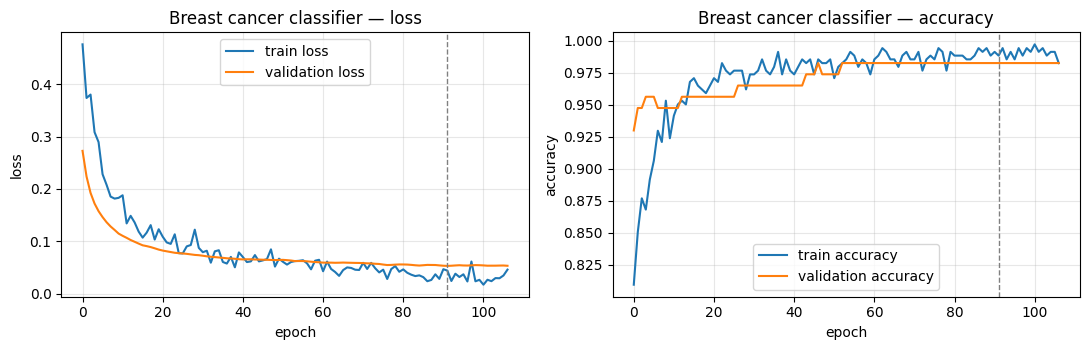

Best epoch (lowest validation loss): 92


In [ ]:
plot_history(history_clf, metric="accuracy", title="Breast cancer classifier")

In [ ]:
test_loss, test_acc, test_auc = clf.evaluate(X_test, y_test, verbose=0)
print(f"Test loss      : {test_loss:.4f}")
print(f"Test accuracy  : {test_acc:.4f}")
print(f"Test AUC       : {test_auc:.4f}\n")

y_prob = clf.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Test loss      : 0.1003
Test accuracy  : 0.9474
Test AUC       : 0.9926

              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



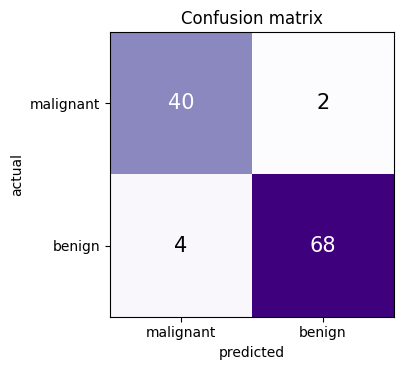

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
ax.imshow(cm, cmap="Purples")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=15, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1], cancer.target_names)
ax.set_yticks([0, 1], cancer.target_names)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

In [ ]:
housing = fetch_california_housing()
Xh, yh = housing.data, housing.target

print("Feature matrix:", Xh.shape)
print("Features:", list(housing.feature_names))
print(f"Target range: {yh.min():.2f} to {yh.max():.2f}  (in $100,000s)")

Xh_tmp, Xh_test, yh_tmp, yh_test = train_test_split(
    Xh, yh, test_size=0.20, random_state=SEED)
Xh_train, Xh_val, yh_train, yh_val = train_test_split(
    Xh_tmp, yh_tmp, test_size=0.25, random_state=SEED)

h_scaler = StandardScaler().fit(Xh_train)
Xh_train = h_scaler.transform(Xh_train)
Xh_val   = h_scaler.transform(Xh_val)
Xh_test  = h_scaler.transform(Xh_test)
print(f"\ntrain {Xh_train.shape[0]}   val {Xh_val.shape[0]}   test {Xh_test.shape[0]}")

Feature matrix: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: 0.15 to 5.00  (in $100,000s)

train 12384   val 4128   test 4128


In [ ]:
reg = keras.Sequential([
    keras.Input(shape=(Xh_train.shape[1],)),
    layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.2),
    layers.Dense(1),                      # linear output — Gaussian p(y|x)
], name="california_housing_regressor")

reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)
reg.summary()

Model: "california_housing_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_reg = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)

history_reg = reg.fit(
    Xh_train, yh_train,
    validation_data=(Xh_val, yh_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop_reg],
    verbose=0,
)
print(f"Stopped after {len(history_reg.history['loss'])} epochs.")

Epoch 127: early stopping
Restoring model weights from the end of the best epoch: 117.
Stopped after 127 epochs.


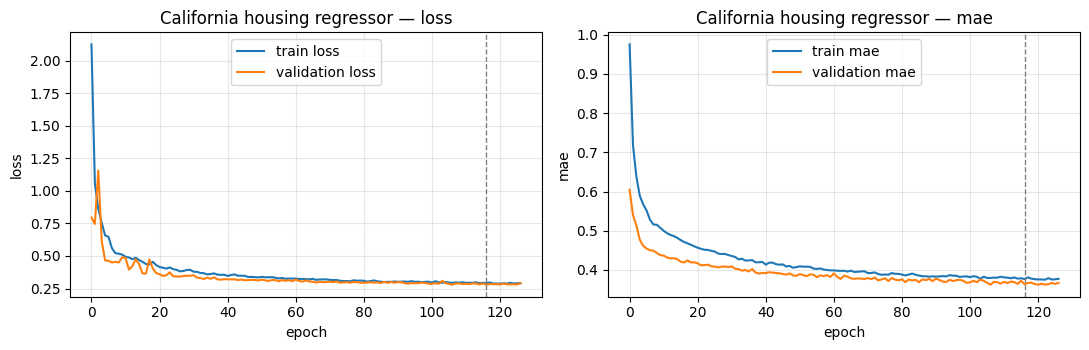

Best epoch (lowest validation loss): 117


In [ ]:
plot_history(history_reg, metric="mae", title="California housing regressor")

In [ ]:
yh_pred = reg.predict(Xh_test, verbose=0).ravel()

mse  = mean_squared_error(yh_test, yh_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(yh_test, yh_pred)
r2   = r2_score(yh_test, yh_pred)

print(f"Test MSE  : {mse:.4f}")
print(f"Test RMSE : {rmse:.4f}   (~ ${rmse * 100_000:,.0f})")
print(f"Test MAE  : {mae:.4f}   (~ ${mae * 100_000:,.0f})")
print(f"Test R²   : {r2:.4f}")

Test MSE  : 0.2764
Test RMSE : 0.5258   (~ $52,576)
Test MAE  : 0.3599   (~ $35,992)
Test R²   : 0.7891


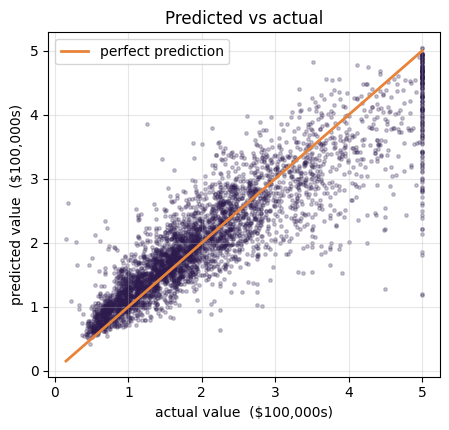

In [ ]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(yh_test, yh_pred, s=6, alpha=0.25, color="#2D1B4E")
lims = [yh_test.min(), yh_test.max()]
ax.plot(lims, lims, color="#E8833A", lw=2, label="perfect prediction")
ax.set_xlabel("actual value  ($100,000s)")
ax.set_ylabel("predicted value  ($100,000s)")
ax.set_title("Predicted vs actual")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()